# Interactive Python using jupyter notebooks

- Notebooks are made of a sequence of cells
- Cells can contain different content such as Python code, or Markdown
- You can change the cell type in the toolbar
- To execute a cell press "Shift+Return"
- Use the tool bar to add, delete, copy, or insert cells

(Note: to learn more about Markdown check [Daring Fireball's website](https://daringfireball.net/projects/markdown/syntax))

## Import the Python package for numerical arrays (numpy)

In [30]:
import numpy as np

## Define a function that creates some statistical data

In [31]:
def load_data():    
    # Goalkeeper, defender, midfielder, attacker
    possible_positions = ['GK', 'D', 'M', 'A']
    N = 100
    positions = []
    heights = []
    for i in range(0,N):
        positions.append(possible_positions[np.random.randint(len(possible_positions))])
        heights.append(np.random.normal(loc=180.0,scale=5.0))
    return positions, heights

## Read the data

In [32]:
positions, heights = load_data()

The objects ```positions``` and ```heights``` are lists as we can check using the Python function ```type```:

In [33]:
print(type(positions))
print(type(heights))

<class 'list'>
<class 'list'>


Question: *How many items are inside the lists ```positions``` and ```heights```?

Hint: Use the Python function ```len```. 

In [34]:
print(f'The position list contains {len(positions)} elements, and the heights list contains {len(heights)} elements.')

The position list contains 100 elements, and the heights list contains 100 elements.


## Convert to numpy arrays

In [35]:
np_positions = np.array(positions)
np_heights = np.array(heights)

Question: *what is the data type of ```np_positions``` and ```np_heights```*?<br>
Question: *what is the shape of ```np_positions``` and ```np_heights```*?


Hint: Numpy objects have member functions called ```dtype``` and ```shape```.

In [36]:
print(f'The datatype of np_positions is {np_positions.dtype}, and the datatype of np_heights is {np_heights.dtype}')
print(f'The shape of np_positions is {np_positions.shape}, and the shape of np_heights is {np_heights.shape}')

The datatype of np_positions is <U2, and the datatype of np_heights is float64
The shape of np_positions is (100,), and the shape of np_heights is (100,)


<U2 means a maximum of 2 chars 

## Extract the heights of the goalkeepers

In [37]:
gk_heights = np_heights[np_positions == 'GK']

## Print the median of the goalkeepers heights

In [38]:
print("Median height of goalkeepers: " + str(np.median(gk_heights)))

Median height of goalkeepers: 180.3920799297226


Question: *what is the median height of all the field players*?<br>
Question: *what is the median height of all the attackers*?<br>
Question: *what is the median height of goalkeepers and the attackers combined?*

In [39]:
M_heights = np_heights[np_positions == 'M']
A_heights = np_heights[np_positions == 'A']
GA_heights = np.hstack((A_heights,gk_heights))

print("Median height of all field players: " + str(np.median(M_heights)))
print("Median height of all attackers: " + str(np.median(A_heights)))
print("Median height of all goalkeepers and attackers combined: " + str(np.median(GA_heights)))


Median height of all field players: 181.1367640926876
Median height of all attackers: 179.31960763167808
Median height of all goalkeepers and attackers combined: 180.1701650591716


## More statistical tests

Besides the ```median```, numpy als comes with the functions ```mean```, ```std```, ```min``` and ```max``` which are useful for investigating statistical data. 

Question: *Who is the shortest player (which position)*?<br>
Question: *Who is the tallest player (which position)*?

In [40]:
index_min = np.where(np_heights == np.min(np_heights))[0][0]
index_max = np.where(np_heights == np.max(np_heights))[0][0]
print(f"I don't know WHO the shortest player is, but he/she is {round(np_heights[index_min],0)} cm tall and plays at the {np_positions[index_min]} position.")
print(f"I don't know WHO the tallest player is, but he/she is {round(np_heights[index_max],0)} cm tall and plays at the {np_positions[index_max]} position.")

I don't know WHO the shortest player is, but he/she is 168.0 cm tall and plays at the GK position.
I don't know WHO the tallest player is, but he/she is 190.0 cm tall and plays at the M position.


## Data plotting

For plotting, we need the package matplotlib

In [41]:
import matplotlib.pyplot as plt

There are different display modes for matplotlib plots inside a jupyter notebook.

In [42]:
# For inline plots use
%matplotlib inline

In [43]:
# For inline plots with interactive capabilities use
#matplotlib notebook

Lets visualize the height distribution of the defenders

In [44]:
d_heights = np_heights[np_positions == 'D']

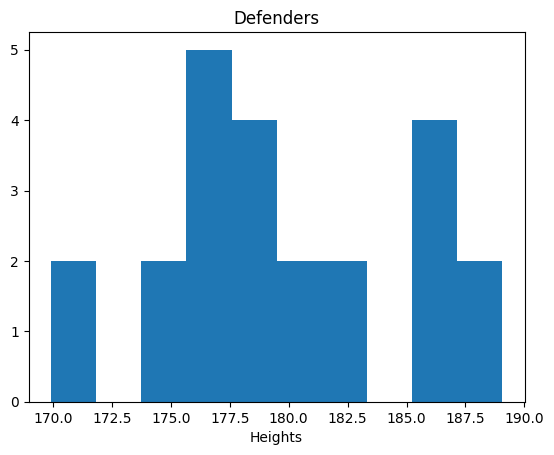

In [45]:
plt.figure()
plt.hist(d_heights)
plt.title('Defenders')
plt.xlabel('Heights')
plt.show()

To figure out the tallest/shortest player, we can the max/min within each position

In [46]:
p = ['GK', 'D', 'M', 'A']
p_max = [np_heights[np_positions == i].max() for i in p]

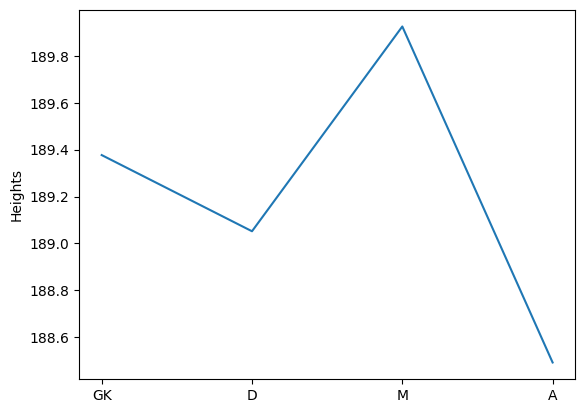

In [47]:
plt.figure()
plt.plot(range(len(p)), p_max)
plt.gca().xaxis.set_ticks(range(len(p)))
plt.gca().xaxis.set_ticklabels(p)
plt.ylabel('Heights')
plt.show()

For inspiration on data plotting and more examples, check out the matplotlib gallery: [https://matplotlib.org/gallery.html](https://matplotlib.org/gallery.html)